# S8 — перенос калибровки между независимыми записями

## tl;dr

Сохранённые residual и tracker residual при истинном CV-состоянии совпадают до машинной точности: ошибки знака/единиц/базиса не обнаружено. На evaluation-сеансе takeoff/hover при +10 dB bearing median ≈0.29°, но pooled recorded-source bias расходится со средним residual на 5–10°; post-hoc `bias=0` при той же R уменьшает условную position RMSE с 12.57–14.48 м до 0.73–0.74 м. **Это анализ уже просмотренных evaluation-данных, а не выбор новой рабочей калибровки.** Покадровые calibration residuals исходных двух сеансов не были сохранены: вклад каждого сеанса, влияние выбросов на pooled bias/R и leave-one-session-out не идентифицируются из pooled моментов.


## Контекст и метод

Читаем только committed `results/s8_tracking_feasibility_*` и историческую pooled calibration. Аудио не генерируется и старые Monte Carlo не повторяются. Два исходных calibration-сеанса и два evaluation-сеанса не позволяют надёжно квалифицировать перенос; зависимые кадры не являются независимыми испытаниями. Bias/R привязаны к `station_id × estimator_variant × source_model`, в prediction-anchored ортонормированном касательном базисе и радианах дуги. Tracker вычисляет `Log_prediction(measurement) - bias`; covariance в рад². Replay меняет только bias; R, события, `Qc`, пороги, бюджет и времена не меняются.


In [1]:
from pathlib import Path
import csv, json, sys
from collections import Counter, defaultdict
import numpy as np
import matplotlib.pyplot as plt
ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / 'results'
def load(name):
    with (RESULTS / name).open(newline='', encoding='utf-8') as handle:
        return list(csv.DictReader(handle))
cal = load('s8_tracking_feasibility_calibration.csv')
residuals = load('s8_calibration_transfer_evaluation_residuals.csv')
pools = load('s8_calibration_transfer_pool_comparison.csv')
replay = load('s8_calibration_transfer_replay.csv')
fits = load('s8_calibration_transfer_hypothesis_diagnostics.csv')
contract = json.loads((RESULTS / 's8_calibration_transfer_contract_audit.json').read_text(encoding='utf-8'))
print('pooled calibration / evaluation groups / replay arms / diagnostics:', len(cal), len(residuals), len(replay), len(fits))
print('contract maximum disagreement (rad):', contract['maximum_tracker_residual_at_truth_disagreement_rad'])


pooled calibration / evaluation groups / replay arms / diagnostics: 12 48 32 208
contract maximum disagreement (rad): 2.220446049250313e-16


## Проверка состава calibration-данных

CSV хранит по одному pooled bias/R на комбинацию source model, станции и метода; `calibration_session_ids_json` — лишь список сеансов, не покадровые residual. Из общей пары моментов нельзя восстановить ни среднее каждого сеанса, ни ковариацию/выбросы внутри него. Поэтому требуемая взаимная проверка `train session A → diagnose B` **не может быть выполнена из сохранённых данных**. Историческая 2-секундная pooled таблица не устраняет эту неидентифицируемость; сравнение ниже показывает только чувствительность pooled итогов к изменению длительности 2→4.5 с.


In [2]:
from validation.s8_calibration_transfer_analysis import assert_calibration_session_grain_available
try:
    assert_calibration_session_grain_available(cal)
except ValueError as exc:
    print('leave-one-calibration-session-out: unavailable —', exc)
for source in ('recorded_source_approximation', 'random_broadband'):
    subset = [row for row in pools if row['source_model_comparison'] == source]
    print(source, 'pooled bias norm range deg:', round(min(float(row['current_pooled_bias_norm_deg']) for row in subset), 3), 'to', round(max(float(row['current_pooled_bias_norm_deg']) for row in subset), 3), 'max 2→4.5s change deg:', round(max(float(row['pooled_bias_duration_change_deg']) for row in subset), 3))


leave-one-calibration-session-out: unavailable — session-grain calibration residuals were not persisted; leave-one-session-out and calibration outlier decomposition are not identifiable
recorded_source_approximation pooled bias norm range deg: 5.394 to 9.7 max 2→4.5s change deg: 9.289
random_broadband pooled bias norm range deg: 0.011 to 0.03 max 2→4.5s change deg: 0.037


## Held-out residual: сеансы, станции, методы и SNR

Это разложение **evaluation**, не утраченного calibration. Серые столбцы показывают средний residual в одном evaluation-сеансе, синие — перенесённый pooled calibration bias (модуль, градусы дуги). Разность не является оценкой статистической неопределённости: кадры перекрываются и коррелированы. Для outlier sensitivity отдельно сохранены полный и 95%-trimmed средние/ковариации evaluation; их нельзя подменять аналогичными величинами calibration.


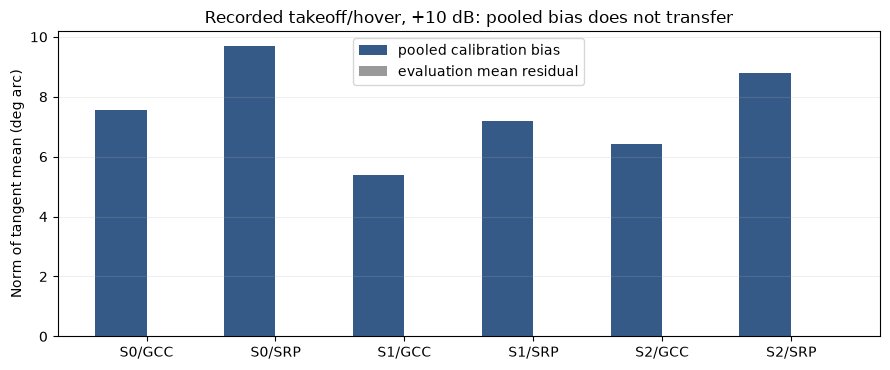

n-audioman-quadcopte -6.0 groups= 6 mean median/P95 deg= 3.55 29.85 mean >30 fraction= 0.054 mean trim shift deg= 0.91
n-audioman-quadcopte 10.0 groups= 6 mean median/P95 deg= 0.29 0.78 mean >30 fraction= 0.0 mean trim shift deg= 0.01
simeonradivoev-mini- -6.0 groups= 6 mean median/P95 deg= 13.11 130.66 mean >30 fraction= 0.449 mean trim shift deg= 5.18
simeonradivoev-mini- 10.0 groups= 6 mean median/P95 deg= 0.33 126.45 mean >30 fraction= 0.401 mean trim shift deg= 5.16


In [3]:
takeoff = [row for row in residuals if row['source_model_comparison']=='recorded_source_approximation' and row['paired_session_id'].startswith('n-audioman') and row['snr_db']=='10.0']
labels = [row['station_id'] + '/' + ('GCC' if row['estimator_variant'].startswith('all_6') else 'SRP') for row in takeoff]
pool_bias = [np.rad2deg(np.hypot(float(row['pooled_calibration_bias_az_arc_rad']),float(row['pooled_calibration_bias_el_arc_rad']))) for row in takeoff]
observed_mean = [float(row['raw_mean_norm_deg']) for row in takeoff]
x = np.arange(len(labels)); fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(x-.2, pool_bias, width=.4, color='#365a88', label='pooled calibration bias')
ax.bar(x+.2, observed_mean, width=.4, color='#999999', label='evaluation mean residual')
ax.set_xticks(x, labels); ax.set_ylabel('Norm of tangent mean (deg arc)')
ax.set_title('Recorded takeoff/hover, +10 dB: pooled bias does not transfer')
ax.legend(); ax.grid(axis='y', alpha=.2); plt.tight_layout(); plt.show()
for session in sorted({row['paired_session_id'] for row in residuals if row['source_model_comparison']=='recorded_source_approximation'}):
    for snr in ('-6.0','10.0'):
        group=[row for row in residuals if row['source_model_comparison']=='recorded_source_approximation' and row['paired_session_id']==session and row['snr_db']==snr]
        print(session[:20], snr, 'groups=',len(group), 'mean median/P95 deg=',round(np.mean([float(r['median_geodesic_error_deg']) for r in group]),2),round(np.mean([float(r['p95_geodesic_error_deg']) for r in group]),2),'mean >30 fraction=',round(np.mean([float(r['fraction_error_gt_30deg']) for r in group]),3),'mean trim shift deg=',round(np.mean([float(r['trimmed_95pct_mean_shift_deg']) for r in group]),2))


## Post-hoc sensitivity replay: pooled bias/R vs bias=0/same R

Все 16 уже просмотренных потоков воспроизведены дважды. Контрольная ветвь сверена с опубликованными финальным статусом, числом updates и conditional position RMSE; позиционная истина присоединяется только **после** выполнения causal estimator. Не сравнивайте RMSE при invalid как ноль: такой оценки нет. Нулевой bias — диагностика переноса, **не** кандидат, выбранный по evaluation.


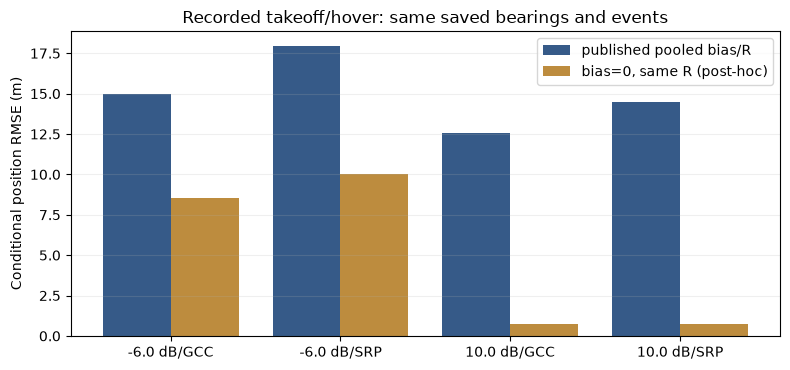

recorded_source_approximation published_pooled_bias_and_R confirmed= 4 / 8 accepted= 36 budget failures= 4
recorded_source_approximation bias_zero_same_R confirmed= 4 / 8 accepted= 36 budget failures= 4
random_broadband published_pooled_bias_and_R confirmed= 6 / 8 accepted= 54 budget failures= 2
random_broadband bias_zero_same_R confirmed= 6 / 8 accepted= 54 budget failures= 2


In [4]:
selected=[row for row in replay if row['source_model_comparison']=='recorded_source_approximation' and row['paired_session_id'].startswith('n-audioman')]
pairs=defaultdict(dict)
for row in selected: pairs[(row['snr_db'],row['estimator_variant'])][row['calibration_variant']]=row
labels=[]; published=[]; zero=[]
for (snr,method),arms in sorted(pairs.items()):
    labels.append(snr+' dB/'+('GCC' if method.startswith('all_6') else 'SRP'))
    published.append(float(arms['published_pooled_bias_and_R']['position_rmse_m_conditional']))
    zero.append(float(arms['bias_zero_same_R']['position_rmse_m_conditional']))
x=np.arange(len(labels)); fig,ax=plt.subplots(figsize=(8,3.8))
ax.bar(x-.2,published,.4,color='#365a88',label='published pooled bias/R')
ax.bar(x+.2,zero,.4,color='#bd8c3e',label='bias=0, same R (post-hoc)')
ax.set_xticks(x,labels);ax.set_ylabel('Conditional position RMSE (m)')
ax.set_title('Recorded takeoff/hover: same saved bearings and events')
ax.legend();ax.grid(axis='y',alpha=.2);plt.tight_layout();plt.show()
for source in ('recorded_source_approximation','random_broadband'):
    for arm in ('published_pooled_bias_and_R','bias_zero_same_R'):
        subset=[r for r in replay if r['source_model_comparison']==source and r['calibration_variant']==arm]
        print(source,arm,'confirmed=',sum(r['final_confirmed']=='True' for r in subset),'/',len(subset),'accepted=',sum(int(r['accepted_update_count']) for r in subset),'budget failures=',sum(r['failure_reason']=='computational_budget_exceeded' for r in subset))


## Почему отказал точный broadband bearing

Для `n-audioman / -6 dB / GCC` ранняя шестисобытийная гипотеза проходит batch gates и становится `tentative`. Подтверждение требует отдельного времени/станций; во время consensus-refit выполняются ещё три batch fits, после чего следующий fit запрещается фиксированным бюджетом 4. Таким образом, статус `computational_budget_exceeded` означает недоведённое подтверждение, а не доказанное несогласие чистых bearings. Таблица ниже сохраняет каждую попытку, IDs, причины и стадии; отобранные гипотезы не называются подтверждёнными.


In [5]:
trace=[r for r in fits if r['source_model_comparison']=='random_broadband' and r['paired_session_id'].startswith('n-audioman') and r['snr_db']=='-6.0' and r['estimator_variant']=='all_6_equal_gcc_wls' and r['calibration_variant']=='published_pooled_bias_and_R' and r['diagnostic_kind']=='batch_fit']
for r in trace: print(f"t={float(r['processing_time_s']):.6f}s | {r['fit_phase']:20s} | count={r['fit_count_after_attempt']} | {r['reason']} | events={len(json.loads(r['construction_event_ids_json']))}")
assert [r['reason'] for r in trace][-1]=='computational_budget_exceeded_before_fit'


t=1.243979s | construction         | count=1 | batch_passed | events=6
t=2.579312s | confirmation_refit   | count=2 | batch_passed | events=7
t=2.594313s | confirmation_refit   | count=3 | batch_passed | events=7
t=2.609312s | confirmation_refit   | count=4 | batch_passed | events=7
t=3.261979s | confirmation_refit   | count=4 | computational_budget_exceeded_before_fit | events=7


## Выводы и ограничения

**Не найдено ошибки реализации** знака, единиц и prediction tangent basis. **Показана непереносимость** pooled recorded-source bias на один evaluation-сеанс и сильные хвосты/различия второго. **Недостаточно сохранённых calibration-данных**, чтобы приписать источник pooled смещения одному сеансу либо количественно оценить leave-one-session-out. Для этого потребуется отдельный разрешённый прогон только calibration-аудио с сохранением per-session residuals; данный анализ аудио не запускает. Broadband-отказ при малой angular error объясняется work budget в подтверждающем refit; менять бюджет по evaluation здесь нельзя. Два сеанса на split остаются слабой диагностической базой.
